## Georg Seismic Experiment

Explore seismic signals at Bonn

## Imports

In [1]:
import os
import gc
import matplotlib.pyplot as plt
import numpy as np
import obspy as obs
import pandas as pd

from obspy.signal import PPSD

from andbro__read_sds import __read_sds
from andbro__compare_psd_stream import __compare_psd_stream

## Configurations

In [2]:
config = {}

config['workdir'] = "/home/andbro/"
# config['workdir'] = "/import/"

config['path_to_inv'] = config['workdir']+"kilauea-data/GEORG/stationxml/"

config['path_to_data'] = config['workdir']+"kilauea-data/GEORG/data/"

config['path_to_figs'] = config['workdir']+"kilauea-data/GEORG/figures/"

# test day
config['tbeg'] = obs.UTCDateTime("2024-12-16 22:00")
config['tend'] = obs.UTCDateTime("2024-12-17 02:00")

# quiet day
config['tbeg'] = obs.UTCDateTime("2024-12-25 00:00")
config['tend'] = obs.UTCDateTime("2024-12-26 00:00")


### Seismometer Data

In [3]:
st_seis = __read_sds(config['path_to_data'], "XN.BONN..BH*", config['tbeg'], config['tend'])

inv_seis = obs.read_inventory(config['path_to_inv']+'station_XN_BONN_centaur.xml')

print(st_seis)

3 Trace(s) in Stream:
XN.BONN..BHE | 2024-12-25T00:00:00.000000Z - 2024-12-26T00:00:00.000000Z | 40.0 Hz, 3456001 samples
XN.BONN..BHN | 2024-12-25T00:00:00.000000Z - 2024-12-26T00:00:00.000000Z | 40.0 Hz, 3456001 samples
XN.BONN..BHZ | 2024-12-25T00:00:00.000000Z - 2024-12-26T00:00:00.000000Z | 40.0 Hz, 3456001 samples


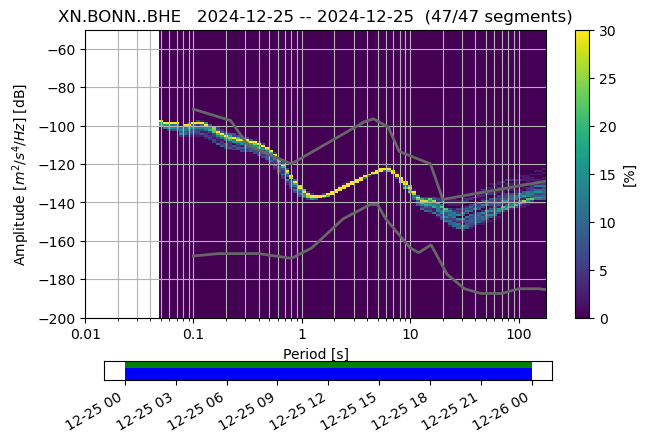

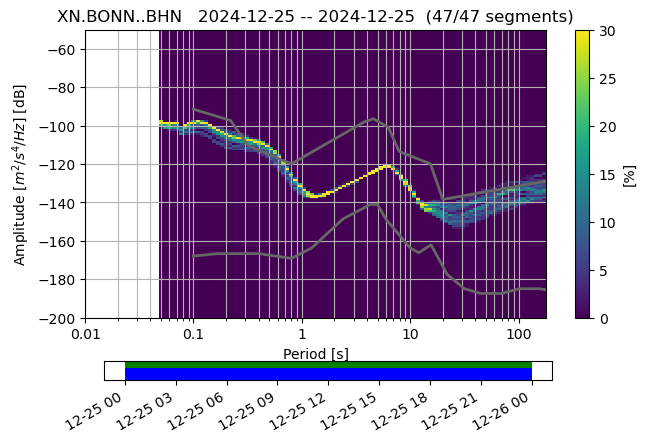

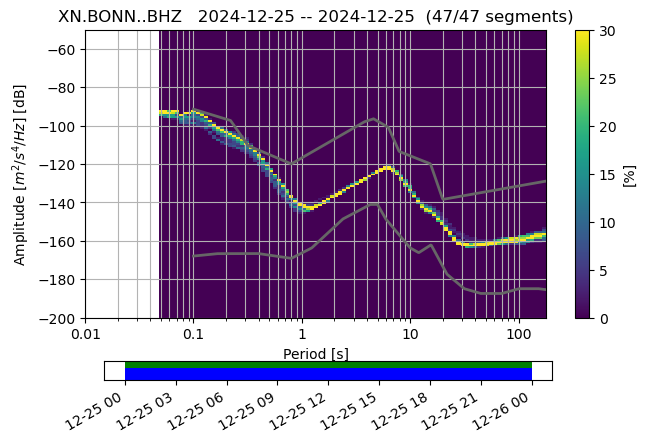

In [4]:
for tr in st_seis:
    ppsd = obs.signal.PPSD(tr.stats, metadata=inv_seis, skip_on_gaps=True)
    ppsd.add(tr)
    ppsd.plot()
    ppsd.plot(filename=config['path_to_figs']+f"ppsd_{tr.get_id()}.png")

### Tiltmeter Data

In [5]:
head = ["time", "north", "east", "X1", "X2", "pressure", "X3", "X4", "X5", "X6"]

tilt = pd.read_csv(config['path_to_data']+"LGMBoxmessung12_16.csv", delimiter=";", names=head)

starttime = obs.UTCDateTime(tilt.time[0])
print(starttime)

mean_dt = tilt.time.diff().mean()
print(mean_dt)

2024-12-16T16:36:15.716615Z
1.0550388852159318


In [6]:
# plt.plot(tilt.time.diff())

In [7]:
st_tilt = __read_sds(config['path_to_data'], "XX.TILT..LA*", config['tbeg'], config['tend'])

print(st_tilt)

2 Trace(s) in Stream:
XX.TILT..LAE | 2024-12-25T00:00:00.567492Z - 2024-12-25T23:59:59.927078Z | 0.9 Hz, 81893 samples
XX.TILT..LAN | 2024-12-25T00:00:00.567492Z - 2024-12-25T23:59:59.927078Z | 0.9 Hz, 81893 samples


In [8]:
for tr in st_tilt:
    tr.data *= 9.81

### RaspShake Data

In [9]:
st_rasp = __read_sds(config['path_to_data'], "AM.RACB0.00.EH*", config['tbeg'], config['tend'])

inv_rasp = obs.read_inventory(config['path_to_inv']+"station_AM_RACB0.xml")


In [10]:
st_rasp

3 Trace(s) in Stream:
AM.RACB0.00.EHE | 2024-12-24T23:59:59.997000Z - 2024-12-25T23:59:59.997000Z | 100.0 Hz, 8640001 samples
AM.RACB0.00.EHN | 2024-12-24T23:59:59.997000Z - 2024-12-25T23:59:59.997000Z | 100.0 Hz, 8640001 samples
AM.RACB0.00.EHZ | 2024-12-24T23:59:59.997000Z - 2024-12-25T23:59:59.997000Z | 100.0 Hz, 8640001 samples

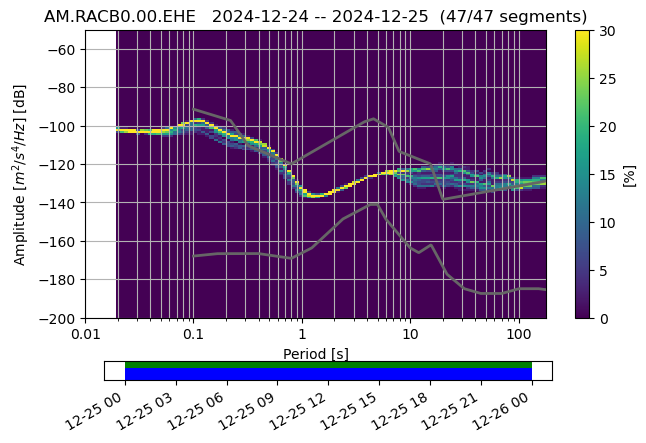

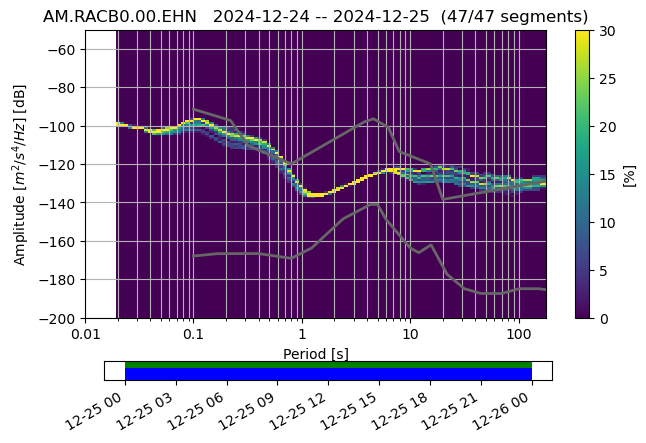

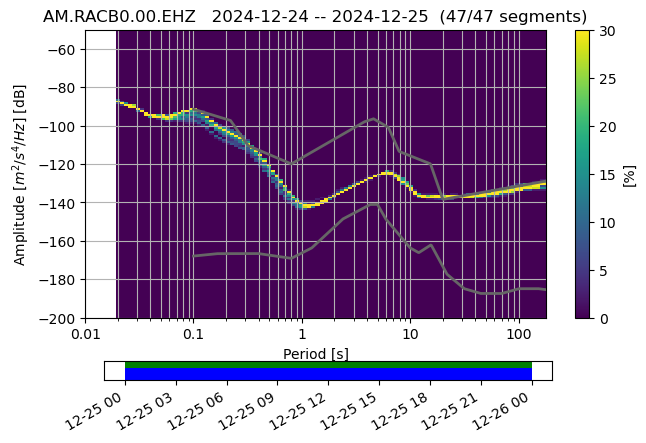

In [11]:
for tr in st_rasp:
    ppsd = obs.signal.PPSD(tr.stats, metadata=inv_rasp)
    ppsd.add(tr)
    ppsd.plot()
    ppsd.plot(filename=config['path_to_figs']+f"ppsd_{tr.get_id()}.png")

## Plot Spectra

In [12]:
st_fur = __read_sds("/bay200/mseed_online/archive/", "GR.FUR..BHZ", config['tbeg'], config['tend'])

inv_fur = obs.read_inventory(config['workdir']+"/kilauea-data/stationxml_ringlaser/station_GR_FUR.xml")


 -> /bay200/mseed_online/archive/ does not exist!


In [13]:
st0 = obs.Stream()

st0 += st_seis.copy().remove_response(inv_seis, output="ACC")
# st0 += st_tilt.copy()
st0 += st_rasp.copy().remove_response(inv_rasp, output="ACC")

try:
    st0 += st_fur.copy().remove_response(inv_fur, output="ACC")
except:
    pass

In [14]:
st2 = st0.copy()

st2 = st2.detrend("demean")

st2 = st2.taper(0.01)

# st2 = st2.resample(1.0, no_filter=False)

fxx, pxx = __compare_psd_stream(st2, twin_sec=7200, psd="welch", plot=False)

# fxx, pxx = __compare_psd_stream(st2, n_win=10, time_bandwidth=3.5, psd="multitaper", plot=False)

fxx2, pxx2 = __compare_psd_stream(st2, twin_sec=300, psd="welch", plot=False)


## Plotting

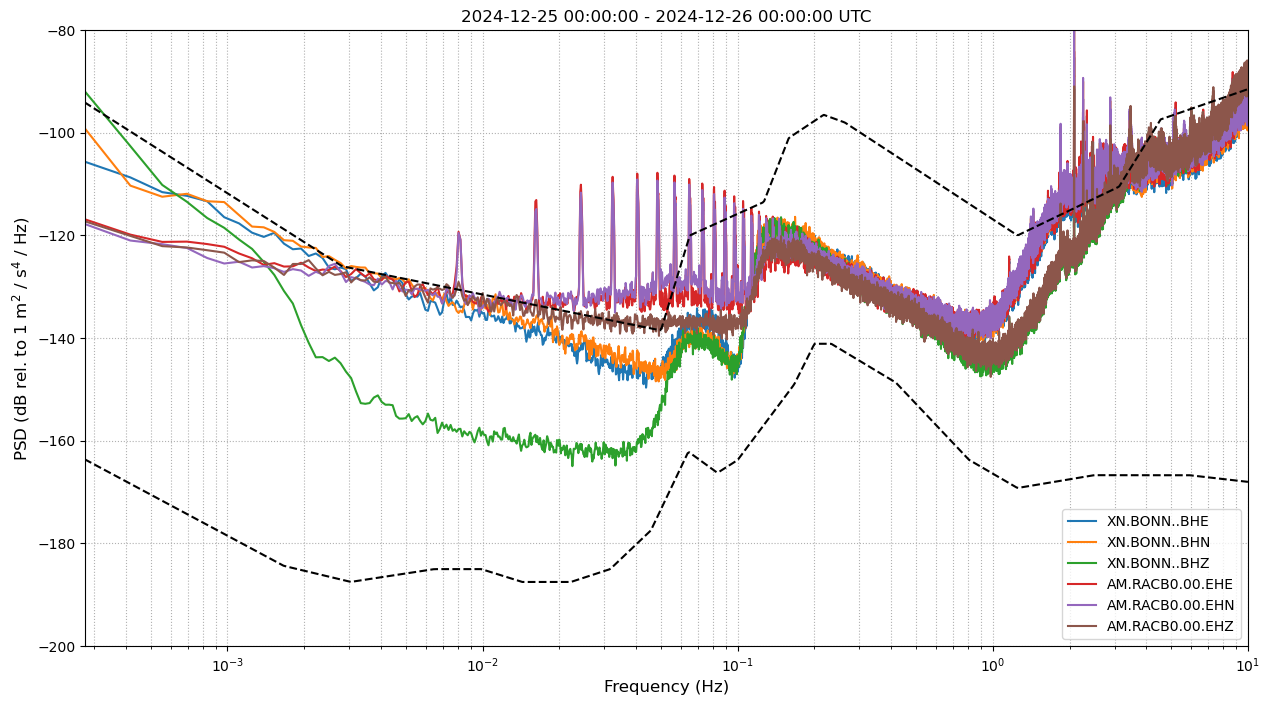

In [15]:
def makeplot():

    Nrow, Ncol = 1, 1

    font = 12

    fig, ax = plt.subplots(Nrow, Ncol, figsize=(15, 8))

    for tr in st2:

        ax.plot(fxx[tr.get_id()], 10*np.log10(pxx[tr.get_id()]), label=tr.get_id())

    try:
        ax.plot(1/models['model_periods'], models['low_noise'], color="k", ls="--")
        ax.plot(1/models['model_periods'], models['high_noise'], color="k", ls="--")
    except:
        pass

    ax.set_xscale("log")
    # ax.set_yscale("log")

    ax.set_ylim(-200, -80)

    ax.grid(which="both", ls=":", zorder=0)
    ax.legend(loc=4)

    fmax = 0.5/tr.stats.delta

    if fmax < 10:
        ax.set_xlim(1/3600, fmax)
    else:
        ax.set_xlim(1/3600, 10)

    ax.set_xlabel(r"Frequency (Hz)", fontsize=font)
    ax.set_ylabel(r"PSD (dB rel. to 1 m$^2$ / s$^4$ / Hz)", fontsize=font)

    ax.set_title(f"{config['tbeg'].date} {config['tbeg'].time} - {config['tend'].date} {config['tend'].time} UTC")

    plt.show();
    return fig

models = np.load(config['workdir']+"kilauea-data/GEORG/data/"+"noise_models.npz")

fig = makeplot()

fig.savefig(config['path_to_figs']+"PSDs.png", format="png", dpi=150, bbox_inches='tight')

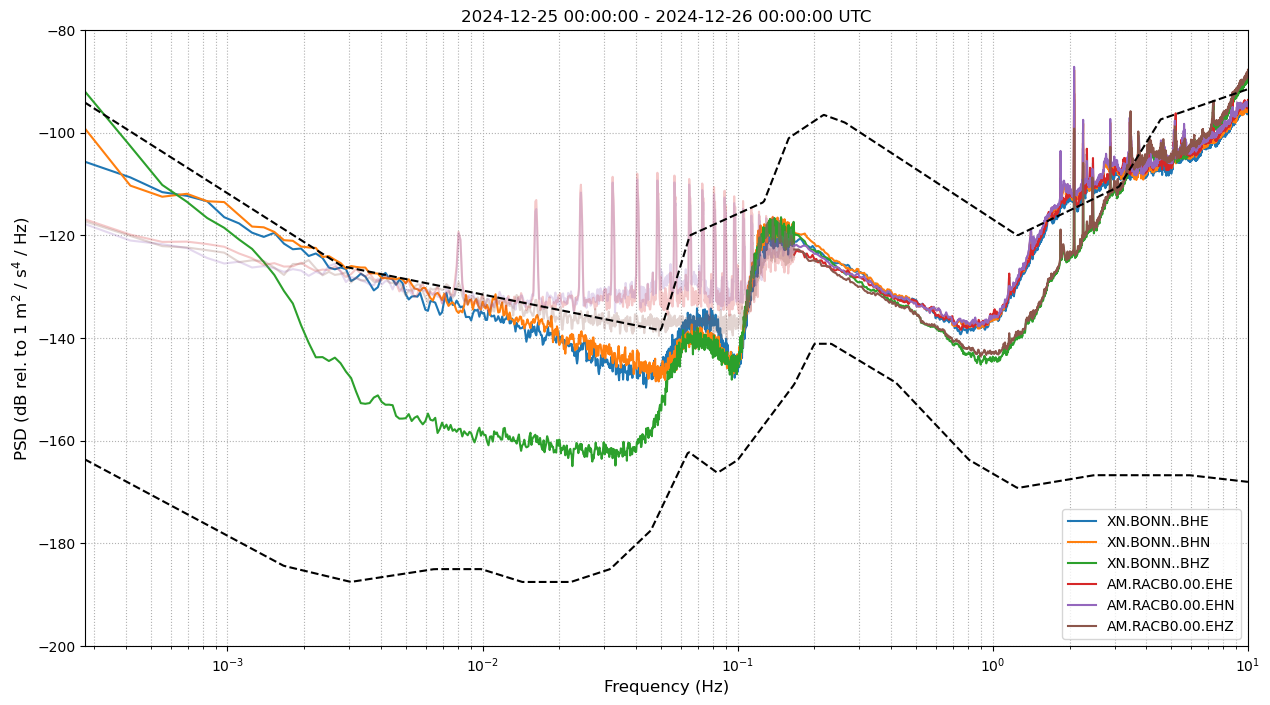

In [16]:
def makeplot2():

    Nrow, Ncol = 1, 1

    font = 12

    fig, ax = plt.subplots(Nrow, Ncol, figsize=(15, 8))

    for tr in st2:

        if "AM" in tr.get_id():
            alpha = 0.25
        else:
            alpha = 1

        N = 1200
        p = ax.plot(fxx[tr.get_id()][:N],
                    10*np.log10(pxx[tr.get_id()])[:N],
                    alpha=alpha,
                   )


        N = 50
        ax.plot(fxx2[tr.get_id()][N:],
                10*np.log10(pxx2[tr.get_id()])[N:],
                label=tr.get_id(),
                color=p[0].get_color(),
               )
    try:
        ax.plot(1/models['model_periods'], models['low_noise'], color="k", ls="--")
        ax.plot(1/models['model_periods'], models['high_noise'], color="k", ls="--")
    except:
        pass

    ax.set_xscale("log")
    # ax.set_yscale("log")

    ax.set_ylim(-200, -80)

    ax.grid(which="both", ls=":", zorder=0)
    ax.legend(loc=4)

    fmax = 0.5/tr.stats.delta

    if fmax < 10:
        ax.set_xlim(1/3600, fmax)
    else:
        ax.set_xlim(1/3600, 10)

    ax.set_xlabel(r"Frequency (Hz)", fontsize=font)
    ax.set_ylabel(r"PSD (dB rel. to 1 m$^2$ / s$^4$ / Hz)", fontsize=font)

    ax.set_title(f"{config['tbeg'].date} {config['tbeg'].time} - {config['tend'].date} {config['tend'].time} UTC")

    plt.show();
    return fig

fig = makeplot2()

fig.savefig(config['path_to_figs']+"PSDs_split.png", format="png", dpi=150, bbox_inches='tight')

## Ringlaser Data

In [49]:
st_georg = obs.read(config['workdir']+"kilauea-data/GEORG/data/2024/XX/GEORG/BJZ.D/XX.GEORG.10.BJZ.D.2024.361")

# inv_georg = obs.read_inventory(config['workdir']+"kilauea-data/GEORG/stationxml/station_XX_GEORG.xml")

# st_georg.remove_sensitivity(inv_georg)

In [18]:
st_rlas = obs.read(config['workdir']+"kilauea-data/GEORG/data/2024/BW/RLAS/BJZ.D/BW.RLAS..BJZ.D.2024.361")

inv_rlas = obs.read_inventory(config['workdir']+"kilauea-data/GEORG/stationxml/station_BW_RLAS.xml")

st_rlas.remove_sensitivity(inv_rlas)

1 Trace(s) in Stream:
BW.RLAS..BJZ | 2024-12-26T00:00:02.331749Z - 2024-12-27T00:00:04.581749Z | 20.0 Hz, 1728046 samples

In [50]:
st_ring = st_georg.copy()
st_ring += st_rlas.copy()

In [51]:
st_ring = st_ring.detrend("demean")

st_ring = st_ring.taper(0.01)

fxx_ring, pxx_ring = __compare_psd_stream(st_ring, twin_sec=7200, psd="welch", plot=False)


In [52]:
models2 = pd.read_csv(config['workdir']+"kilauea-data/GEORG/data/"+"RLNM_model_data.csv")

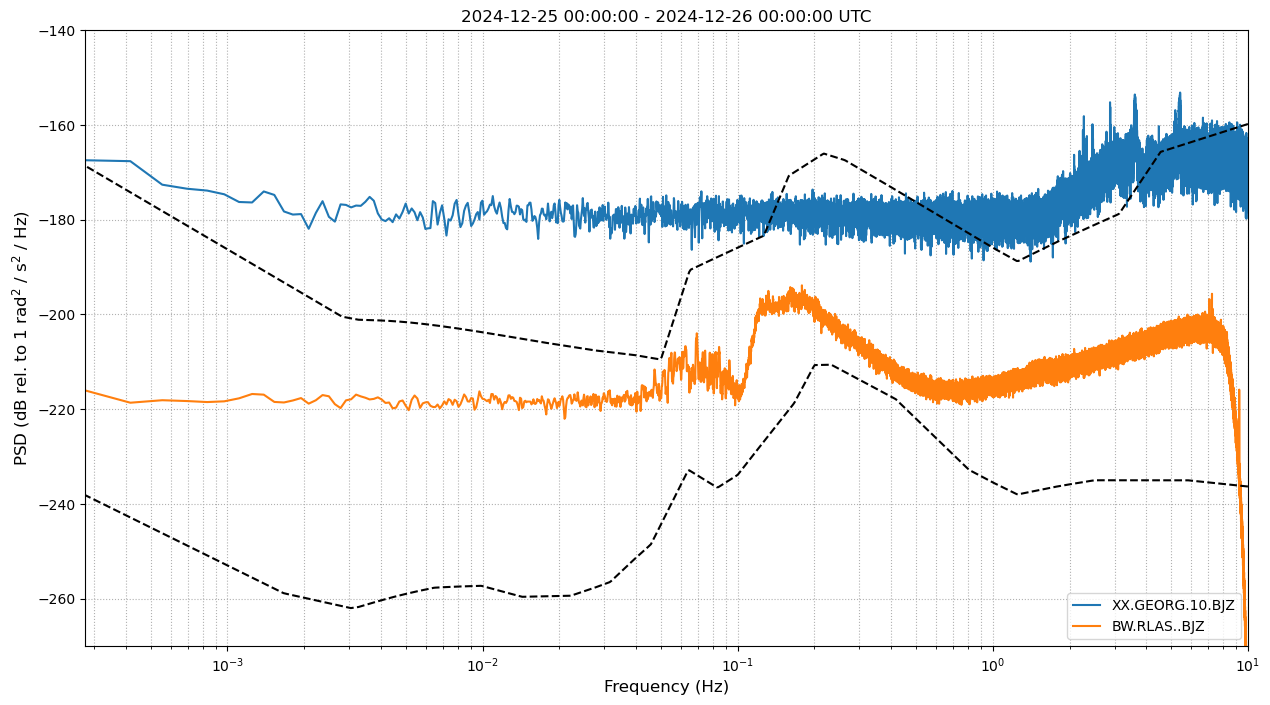

In [56]:
def makeplot_ring():

    Nrow, Ncol = 1, 1

    font = 12

    fig, ax = plt.subplots(Nrow, Ncol, figsize=(15, 8))

    ax.plot(fxx_ring['XX.GEORG.10.BJZ'], 10*np.log10(pxx_ring['XX.GEORG.10.BJZ']), label='XX.GEORG.10.BJZ')
    ax.plot(fxx_ring['BW.RLAS..BJZ'], 10*np.log10(pxx_ring['BW.RLAS..BJZ']), label='BW.RLAS..BJZ')

    ax.plot(models2['frequency'], 10*np.log10(models2['rlnm_rot_rate']), color="k", ls="--")
    ax.plot(models2['frequency'], 10*np.log10(models2['rhnm_rot_rate']), color="k", ls="--")

    ax.set_xscale("log")
    # ax.set_yscale("log")

    ax.set_ylim(-270, -140)

    ax.grid(which="both", ls=":", zorder=0)
    ax.legend(loc=4)

    fmax = 0.5/tr.stats.delta

    if fmax < 10:
        ax.set_xlim(1/3600, fmax)
    else:
        ax.set_xlim(1/3600, 10)

    ax.set_xlabel(r"Frequency (Hz)", fontsize=font)
    ax.set_ylabel(r"PSD (dB rel. to 1 rad$^2$ / s$^2$ / Hz)", fontsize=font)

    ax.set_title(f"{config['tbeg'].date} {config['tbeg'].time} - {config['tend'].date} {config['tend'].time} UTC")

    plt.show();
    return fig

fig = makeplot_ring()

fig.savefig(config['path_to_figs']+"PSDs_rings.png", format="png", dpi=150, bbox_inches='tight')

In [59]:
stx = obs.read(config['workdir']+"kilauea-data/GEORG/data/2024/XX/GEORG/FJZ.D/XX.GEORG..FJZ.D.2024.361")

In [57]:
stx = __read_sds(config['workdir']+"kilauea-data/GEORG/data/", "XX.GEORG..FJZ", "2024-12-26 00:00", "2024-12-26 00:30")

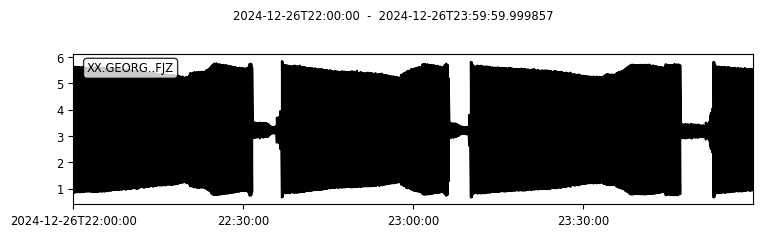

In [60]:
stx.plot();

In [ ]:
plt.plot(stx[0].data[:300])

In [ ]:
6_319_100_000_000

In [ ]:
4*16/16/632.8e-9